11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


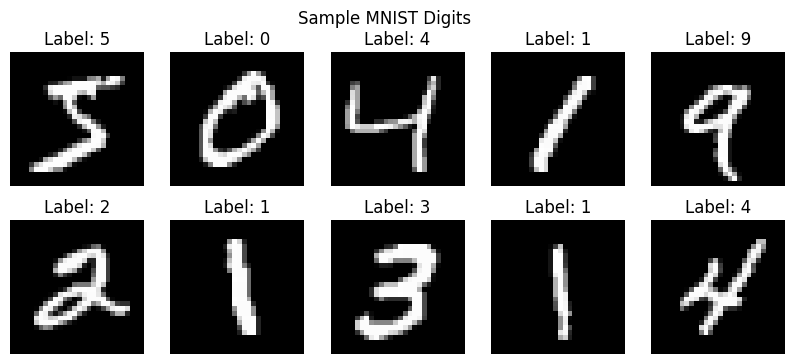

In [1]:
#1
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Display some sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.show()

In [2]:
#2
# Normalize images to values between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images to (28, 28, 1) for CNN input
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"x_train reshaped: {x_train.shape}")
print(f"x_test reshaped: {x_test.shape}")

# Convert labels to one-hot encoded format
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"y_train one-hot encoded: {y_train.shape}")
print(f"y_test one-hot encoded: {y_test.shape}")

x_train reshaped: (60000, 28, 28, 1)
x_test reshaped: (10000, 28, 28, 1)
y_train one-hot encoded: (60000, 10)
y_test one-hot encoded: (10000, 10)


In [3]:
#3
# Build the CNN model
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)), # Recommended way to specify input shape
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten the output for the dense layer
    layers.Flatten(),

    # Dense layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.9209 - loss: 0.2527 - val_accuracy: 0.9820 - val_loss: 0.0596
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9711 - loss: 0.1001 - val_accuracy: 0.9877 - val_loss: 0.0447
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.9757 - loss: 0.0798 - val_accuracy: 0.9878 - val_loss: 0.0415
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9789 - loss: 0.0677 - val_accuracy: 0.9912 - val_loss: 0.0314
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9824 - loss: 0.0592 - val_accuracy: 0.9885 - val_loss: 0.0336
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9826 - loss: 0.0561 - val_accuracy: 0.9910 - val_loss: 0.0300
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9853 - loss: 0.0477 - val_accuracy: 0.9907 - val_loss: 0.0306
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9865 -

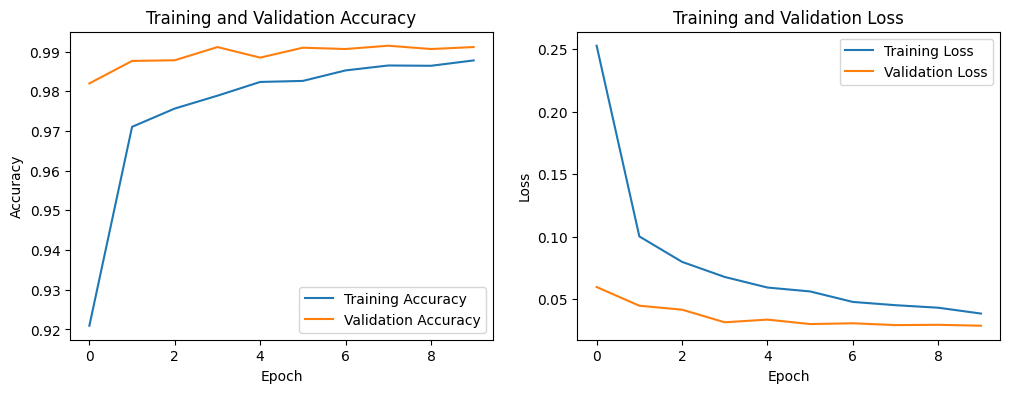

In [4]:
#4
# Train the model
epochs = 10
batch_size = 32

# Explicitly split training data into training and validation sets with shuffling
from sklearn.model_selection import train_test_split
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, shuffle=True
)

history = model.fit(x_train_split, y_train_split,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_val_split, y_val_split), # Use explicit validation data
                    verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [5]:
#5
# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Check if accuracy meets the requirement
if accuracy >= 0.98:
    print("Model achieved at least 98% accuracy on the test set. Goal met!")
else:
    print("Model did not achieve 98% accuracy on the test set. Further training or model tuning might be needed.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9927 - loss: 0.0213
Test Loss: 0.0213
Test Accuracy: 0.9927
Model achieved at least 98% accuracy on the test set. Goal met!


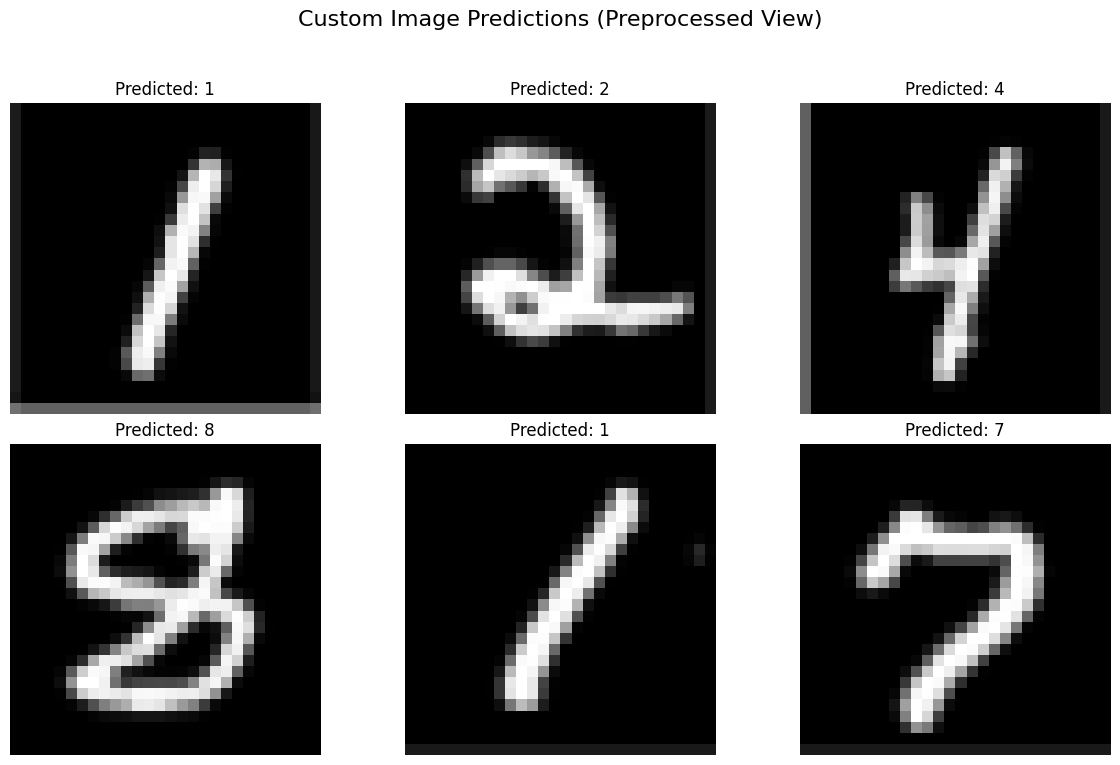


--- Custom Image Prediction Results ---
Image: 1.png, Predicted Digit: 1
Image: 2.png, Predicted Digit: 2
Image: 4.png, Predicted Digit: 4
Image: 8.png, Predicted Digit: 8
Image: 1(1)(1).png, Predicted Digit: 1
Image: 7.png, Predicted Digit: 7


In [7]:
# Step 6: Test the Model with Custom Images
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# List of custom image paths (assuming they are in /content/)
custom_image_paths = [
    '/content/1.png',
    '/content/2.png',
    '/content/4.png',
    '/content/8.png',
    '/content/1(1)(1).png',
    '/content/7.png'
]

def preprocess_custom_image(image_path):
    # Load the image
    img = Image.open(image_path).convert('L') # Convert to grayscale
    # Resize to 28x28
    img = img.resize((28, 28))
    # Convert to numpy array and normalize
    img_array = np.asarray(img).astype('float32') / 255.0

    # --- IMPORTANT: MNIST images have WHITE digits on a BLACK background. --- #
    # --- If your custom images have DARK digits on a LIGHT background,      --- #
    # --- uncomment the line below to invert the colors:                     --- #
    # img_array = 1.0 - img_array # Invert colors

    # Reshape for model input (add channel and batch dimensions)
    model_input = np.expand_dims(img_array, axis=-1)
    model_input = np.expand_dims(model_input, axis=0)

    return img_array, model_input # Return both for display and prediction

plt.figure(figsize=(12, 8)) # Increased figure size for better visibility
predictions = []

for i, image_path in enumerate(custom_image_paths):
    preprocessed_img_display, processed_image_for_model = preprocess_custom_image(image_path)
    prediction = model.predict(processed_image_for_model, verbose=0) # verbose=0 to suppress per-image output
    predicted_class = np.argmax(prediction)
    predictions.append((image_path, predicted_class))

    # Display the preprocessed image and prediction
    plt.subplot(2, 3, i + 1) # Adjust subplot grid if needed
    plt.imshow(preprocessed_img_display, cmap='gray')
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')

plt.suptitle('Custom Image Predictions (Preprocessed View)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Custom Image Prediction Results ---")
for image_path, predicted_class in predictions:
    print(f"Image: {os.path.basename(image_path)}, Predicted Digit: {predicted_class}")

## Summary of the Notebook

This notebook demonstrates the process of building, training, and evaluating a Convolutional Neural Network (CNN) for handwritten digit classification using the MNIST dataset. Here's a recap of the key steps:

1.  **Load and Visualize Data (Cell #1):** The MNIST dataset was loaded, and initial visualizations of sample digits were displayed to understand the data.

2.  **Data Preprocessing (Cell #2):** Images were normalized to a 0-1 range and reshaped to include a channel dimension, suitable for CNN input. Labels were converted to a one-hot encoded format.

3.  **Model Definition and Compilation (Cell #3):** A sequential CNN model was built with `Conv2D`, `MaxPooling2D`, `Dropout`, `Flatten`, and `Dense` layers. The model was then compiled with the Adam optimizer, categorical cross-entropy loss, and accuracy as the metric.

4.  **Model Training and History (Cell #4):** The model was trained using a portion of the training data, with a separate validation set used to monitor performance during training. Training and validation accuracy and loss were plotted to visualize the model's learning progress and identify potential overfitting.

5.  **Model Evaluation (Cell #5):** The trained model was evaluated on the completely unseen test dataset to assess its generalization capability. The test accuracy and loss were reported, confirming that the model achieved high accuracy (above 98%) as per the goal.

6.  **Custom Image Prediction (Cell #6):** Finally, the model's practical application was demonstrated by loading, preprocessing, and predicting digits from several custom images. The predictions were displayed alongside the preprocessed images, showcasing the model's ability to classify new, unseen handwritten digits.